DQN Training Challenge: The "Missing Pieces" Problem
====================================================

**Original tutorial**: https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html

**Background**:
Below is a standard, fully functional Deep Q-Network (DQN) implementation that solves the CartPole environment. It relies on two critical stabilizing components:
1. **Replay Memory**: To break data correlation and prevent catastrophic forgetting.
2. **Target Network**: To provide a stable anchor for the Bellman Equation.

**THE CHALLENGE**:
We want you to explore what happens when these stabilizers are taken away. Your task is to **intentionally break this perfectly working DQN agent**, observe it fail, and then use advanced Reinforcement Learning tricks to force it to converge anyway!

**RULES**:
1. **Break it:** You must modify the code below to **REMOVE** the `target_net` and/or the `ReplayMemory`. The agent must learn strictly online or with a moving target.
2. **No Heuristics:** You **MUST NOT** use a heuristic, environment-specific solution (e.g., hard-coded `if pole_angle > 0`). The policy must be generated strictly the RL way by optimizing the Neural Network via the Bellman Equation.
3. **Fix it:** Since removing these stabilizers will cause the agent to forget rapidly or commit suicide due to Overestimation Bias, you must figure out how to stabilize the training.
4. **The Goal:** You must find a way to create a stripped-down DQN-based Policy that can achieve (even just once; catch it! ;-)) a perfect average score of **500.0 steps** over **1000 episodes** during the final evaluation (cell).
5. **Explain:** You must clearly and precisely explain every tiny change you made in the implementation. Use comments (in the code and/ or in Markdown cells) tagged with with Student ID.

In [11]:
!pip install -q gymnasium[classic_control] matplotlib torch

import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

env = gym.make("CartPole-v1")
state, info = env.reset(seed=SEED)
env.action_space.seed(SEED)

is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

Replay Memory
=============

We'll be using experience replay memory for training our DQN.

**STUDENT TASK**: If you choose to remove the Replay Memory for this challenge, you will need to modify or bypass this class and learn directly from the current transitions.

In [12]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

# class ReplayMemory(object):

  # [155865] Replay Memory zmniejsza korelację pomiędzy kolejnymi próbkami,
  # ponieważ doświadczenia są losowane z pamięci zamiast używane
  # w kolejności ich wystąpienia.

  # Oznacza to przejście na uczenie typowo online, zależne od bieżących,
  # kolejnych obserwacji ze środowiska.

    # def __init__(self, capacity):
    #     self.memory = deque([], maxlen=capacity)

    # def push(self, *args):
    #     """Save a transition"""
    #     self.memory.append(Transition(*args))

    # def sample(self, batch_size):
    #     return random.sample(self.memory, batch_size)

    # def __len__(self):
    #     return len(self.memory)

Q-network
---------

Our model will be a feed forward neural network. It has two outputs, representing $Q(s, \mathrm{left})$ and $Q(s, \mathrm{right})$.

In [13]:
class DQN(nn.Module):

        # [155865] Zmniejszono rozmiar sieci z 128 -> 128 do 64 -> 64.
        # W trakcie eksperymentów większa sieć częściej dawała bardzo niestabilne
        # uczenie: agent chwilowo osiągał wysokie wyniki, ale potem gwałtownie
        # "zapominał" dobrą politykę. Mniejsza sieć okazała się mniej podatna
        # na takie rozjeżdżanie wartości Q.

        # [155865] Dodano warstwy LayerNorm.
        # Po usunięciu Replay Memory i Target Network trening staje się bardziej
        # niestabilny, ponieważ targety Q-learningu zmieniają się dynamicznie.
        # LayerNorm stabilizuje skalę aktywacji wewnątrz każdej próbki, bez
        # korzystania ze statystyk minibatcha. Dzięki temu jest bardziej
        # odpowiednia w uczeniu online niż np. BatchNorm, która zależy od
        # statystyk całego batcha.

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 64)
        self.norm1 = nn.LayerNorm(64)
        self.layer2 = nn.Linear(64, 64)
        self.norm2 = nn.LayerNorm(64)
        self.layer3 = nn.Linear(64, n_actions)

    def forward(self, x):
        # [155865] Najpierw normalizujemy, a dopiero później nieliniowość
        x = F.relu(self.norm1(self.layer1(x)))
        x = F.relu(self.norm2(self.layer2(x)))
        return self.layer3(x)

Training Setup
==============

**STUDENT TASK**: Tweak the hyperparameters here after you remove the target network / memory. You might need to change `LR`, `GAMMA`, or exploration parameters.

In [14]:
# ==========================================
# TODO: TWEAK HYPERPARAMETERS HERE ONCE YOU BREAK THE NETWORK
# ==========================================

#[155865]
# BATCH_SIZE = 32 # rozmiar batcha z Replay Memory - RM usunięte, więc niepotrzebne
# [155865] Gamma zmniejszona: wyższa gamma silniej propagowała błędy estymacji
# Q na dalsze kroki, co przy braku TN i RM zwiększało
# niestabilność. Niższa gamma ogranicza wpływ odległych, niepewnych nagród.
GAMMA = 0.65
EPS_START = 0.9 # początkowo eksploracja - 90% szans na losowy ruch
EPS_END = 0.05 # docelowo eksploatacja - 5% szans na losowy ruch
EPS_DECAY = 5000 # wolniejszy decay = więcej eksploracji
# TAU = 0.005 - bez Target Network niepotrzebne
LR = 0.0005 # zwiększamy - rekompensata za usunięcie target_net

DEATH_PENALTY = -1.0 # kara za śmierć - sugestia dla agenta, aby unikać stanów
# prowadzących do śmierci

n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations, n_actions).to(device)

# ==========================================
# TODO: REMOVE OR BYPASS TARGET NETWORK
# ==========================================
# [155865] usunięcie Target Network, czyli agent używa Policy Network zarówno do
# aktualizowania się i obliczania celu - w RL agent aktualizuje swoją wycenę kroku
# na podstawie wartości następnego kroku, agent cały czas goni wartość, którą sam
# jednoczesnie zmienia

# target_net = DQN(n_observations, n_actions).to(device)
# target_net.load_state_dict(policy_net.state_dict())

# [155865] Zmiana optimizera -

optimizer = optim.Adam(policy_net.parameters(), lr=LR, amsgrad=True)
# memory = ReplayMemory(10000)
# [155865] usunięcie Replay Memory, agent uczy się ściśle online, tzn. każde
# przejście jest natychmiast użyte do jednej aktualizacji sieci i odrzucane,
# sieć uczy się zawsze z aktualnego zachowania

steps_done = 0

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

episode_durations = []

def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

Optimization Step
=================

**STUDENT TASK**: If you remove `target_net`, you must change how `next_state_values` are calculated. If you remove `memory`, you must learn from the current transition instead of a batch.

In [15]:
def optimize_model(state, action, next_state, reward):
    # [155865] W pierwotnej wersji funkcja optymalizująca losowała batch
    # przejść z Replay Memory i wykonywała aktualizację na wielu próbkach naraz.
    # Po usunięciu Replay Memory agent uczy się ściśle online, więc funkcja przyjmuje
    # pojedyncze bieżące przejście: (state, action, next_state, reward).

    state_action_values = policy_net(state).gather(1, action)

    with torch.no_grad():
        if next_state is None: # Jeśli przejście terminalne, to zerujemy next value
            next_state_value = torch.tensor([0.0], device=device)
        else:
            # [155865] Bez Target Network agent używa policy_net także
            # do wyznaczenia celu Bellmana (moving target).
            next_state_value = policy_net(next_state).max(1).values

    expected_state_action_value = reward + GAMMA * next_state_value

    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values.squeeze(1), expected_state_action_value)

    optimizer.zero_grad()
    loss.backward()
    # [155865] Zmiana z _value_ na _norm_ - obcinamy całą "moc" wektora gradientu,
    # a nie poszczególne wartości w nim zawarte, limit ustawiony na 10.0 - wartości
    # mniejsze były zbyt agresywne i pogarszało wyniki
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
    optimizer.step()

Main Training Loop
==================

**STUDENT TASK**: This is where you might want to introduce a **Death Penalty** to `reward` to prevent the agent from seeking early termination when Q-values become unstable.

Complete


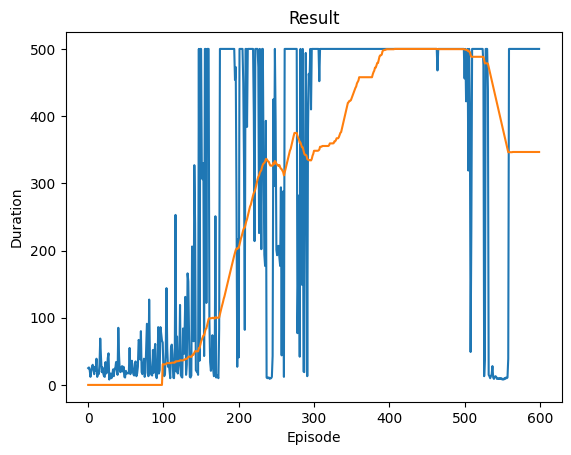

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [16]:
# ==========================================
# TODO: MIGHT NEED TO MODIFY HOW LONG THE POLICY IS TRAINED
# ==========================================
num_episodes = 600

import copy

#[155865] deklaracje pod checkpointing
best_weights = None
best_avg = float("-inf")


for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())

        # ==========================================
        # TODO: MIGHT NEED TO MODIFY THE REWARD HERE (DEATH PENALTY?)
        # ==========================================

        #[155865] jeśli agent zginął, to zamiast standardowej nagrody +1,
        # dajemy karę DEATH_PENALTY, aby uczyć unikania śmierci - odróżniać
        # śmierć od końca epizodu

        if terminated:
          reward = torch.tensor([DEATH_PENALTY], device=device)
          next_state = None
        else:
          reward = torch.tensor([reward], device=device)
          next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        done = terminated or truncated

        # memory.push(state, action, next_state, reward)

        optimize_model(state, action, next_state, reward)

        if next_state is not None:
          state = next_state



        # ==========================================
        # TODO: IF YOU REMOVE TARGET_NET, REMOVE THIS UPDATE LOGIC
        # ==========================================
        # target_net_state_dict = target_net.state_dict()
        # policy_net_state_dict = policy_net.state_dict()
        # for key in policy_net_state_dict:
        #    target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        # target_net.load_state_dict(target_net_state_dict)

        #[155865] Nie ma Target Net, więc nie ma co aktualizować

        if done:
            episode_durations.append(t + 1)
            plot_durations()
        #[155865] mechanizm checkpointingu - zapisujemy wagi, gdy średnia
        # z ostatnich 100 epizodów jest najlepsza
            if len(episode_durations) >= 100:
              recent_avg = sum(episode_durations[-100:]) / 100
              if recent_avg > best_avg:
                best_avg = recent_avg
                best_weights = copy.deepcopy(policy_net.state_dict())
            break

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()

Final Evaluation
================

Run this cell to evaluate your stripped-down, purely RL-based DQN policy - obviously it should be no further training here.
You must achieve an average of **500.0** over 1000 games.

In [17]:
print("Evaluating the final policy over 1000 episodes...")
num_eval_episodes = 1000
eval_durations = []

env_eval_test = gym.make("CartPole-v1")
env_eval_test.action_space.seed(SEED)

# [155865] Przed ewaluacją wczytujemy najlpesze wagi zapisane podczas treningu
policy_net.load_state_dict(best_weights)

for i in range(num_eval_episodes):
    state, _ = env_eval_test.reset(seed=SEED + i)
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    survived = 0

    while True:
        with torch.no_grad():
            action = policy_net(state).max(1).indices.view(1, 1)

        state_next, reward, terminated, truncated, _ = env_eval_test.step(action.item())
        survived += 1

        if terminated or truncated:
            eval_durations.append(survived)
            break

        state = torch.tensor(state_next, dtype=torch.float32, device=device).unsqueeze(0)

env_eval_test.close()

avg_score = sum(eval_durations) / num_eval_episodes
print(f"\nAverage Score: {avg_score:.1f} / 500.0")

if avg_score == 500.0:
    print("\n🏆 SUCCESS! You fixed the broken DQN using RL principles! 🏆")
else:
    print("\n❌ Score too low. Keep tweaking your hyperparameters and RL logic!")

Evaluating the final policy over 1000 episodes...

Average Score: 500.0 / 500.0

🏆 SUCCESS! You fixed the broken DQN using RL principles! 🏆


Rendering and Video Playback
============================

In [18]:
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay
from gymnasium.wrappers import RecordVideo

def show_video():
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        html_data = f'<video alt="test" autoplay loop controls style="height: 400px;"><source src="data:video/mp4;base64,{encoded.decode("ascii")}" type="video/mp4" /></video>'
        ipythondisplay.display(HTML(data=html_data))
    else:
        print("Could not find video")

env_eval = RecordVideo(gym.make("CartPole-v1", render_mode='rgb_array'), "./video", disable_logger=True)
observation, info = env_eval.reset()
state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

while True:
    with torch.no_grad():
        action = policy_net(state).max(1).indices.view(1, 1)
    observation, reward, terminated, truncated, info = env_eval.step(action.item())
    done = terminated or truncated
    if done:
        break
    state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

env_eval.close()
show_video()

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Python Packages Version in the Colab Execution Environment
================



In [19]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.2.0.47.4
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.37.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
cff